C:\Users\laank\AppData\Local\Temp\ipykernel_27448\3092378772.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(csv_files))


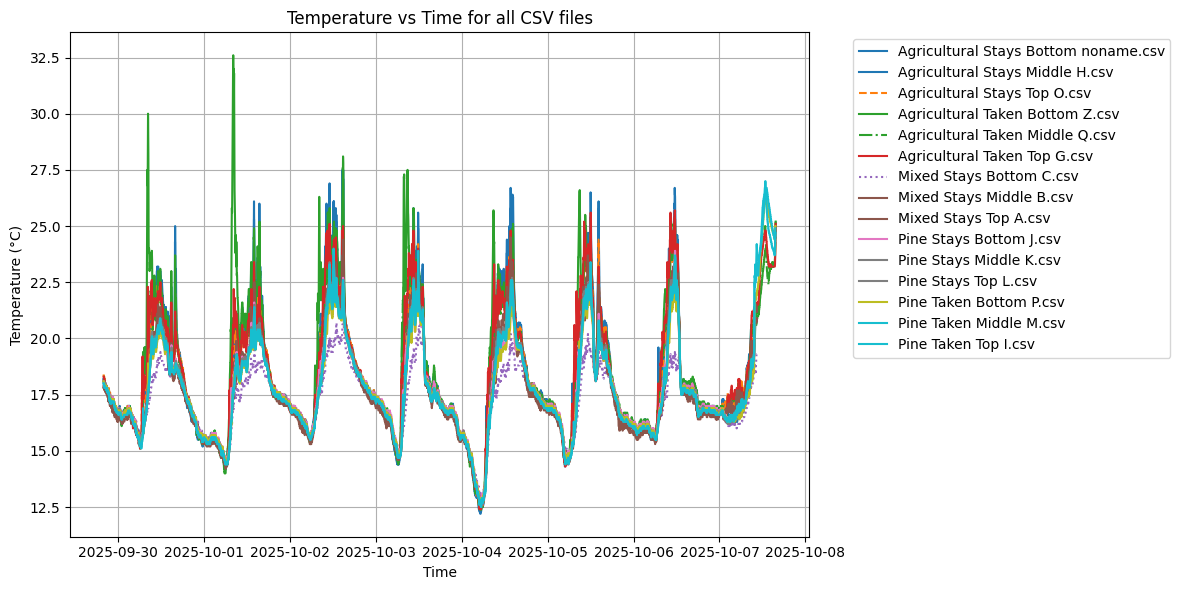

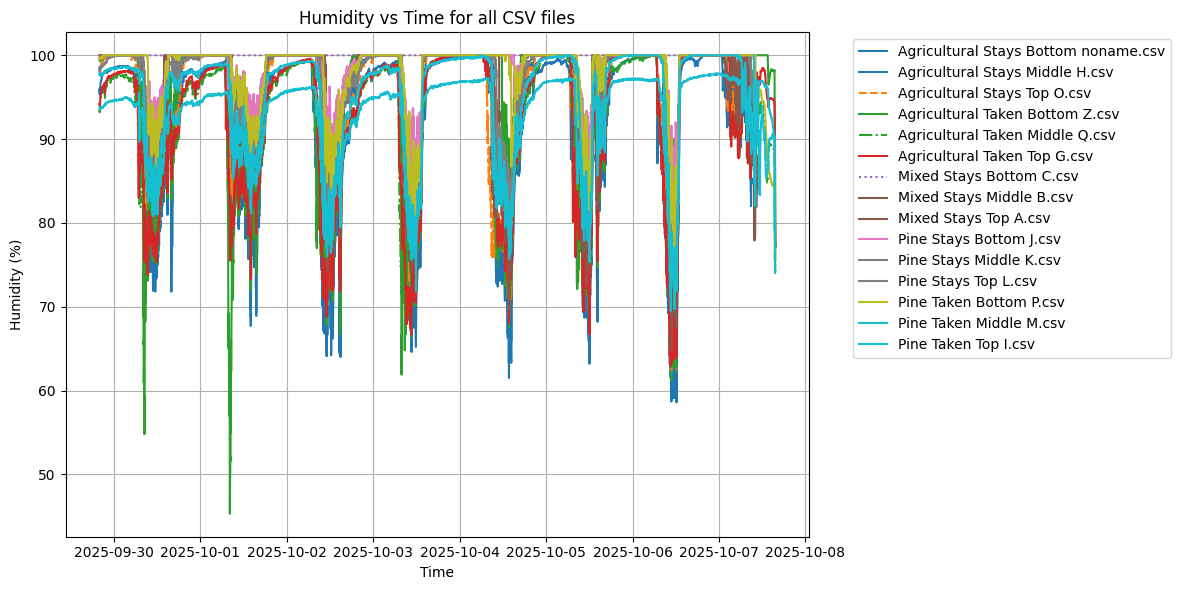

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob

csv_files = glob.glob("*.csv")

# csv_files = ["Cloud For Low Base.csv", "Cloud For High Base.csv", "Pine Low Base.csv","Pine High Base.csv", "Tower Base.csv"]

colors = cm.get_cmap('tab10', len(csv_files))

special_styles = {
    2: '--', 
    4: '-.',   
    6: ':'     
}

# --- TEMPERATURE PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep=",", 
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Temp"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


# --- HUMIDITY PLOT ---
plt.figure(figsize=(12,6))

for i, name in enumerate(csv_files):
    df = pd.read_csv(
        name, 
        sep= ',',
        decimal=".", 
        usecols=[0,1,2,3,4],  
        header=None,
        names=["ID", "Date", "Time", "Temp", "Humidity"]
    )
    
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str), errors="coerce")
    
    style = special_styles.get(i, '-') 
    plt.plot(df["Datetime"], df["Humidity"], label=name, color=colors(i), linestyle=style)

plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.title("Humidity vs Time for all CSV files")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.tight_layout()
plt.show()


C:\Users\laank\AppData\Local\Temp\ipykernel_13352\3900997156.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(files))  # colorblind-friendly


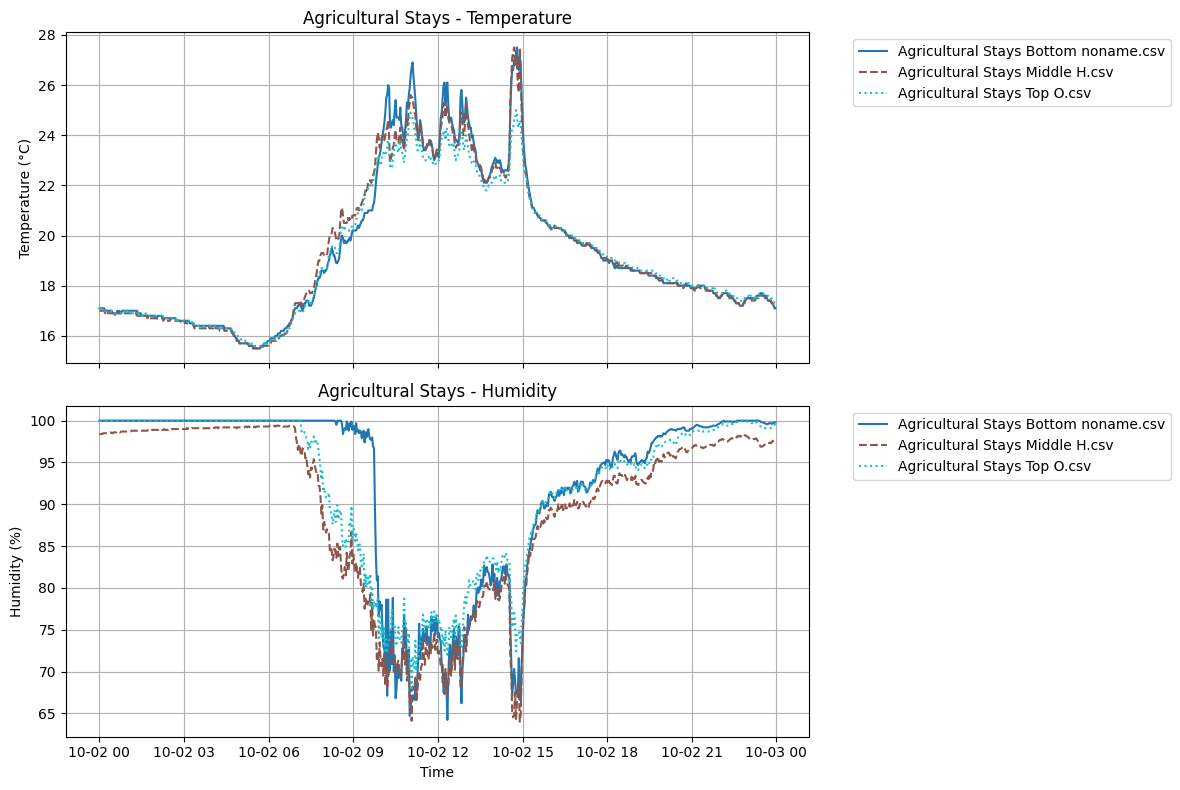

C:\Users\laank\AppData\Local\Temp\ipykernel_13352\3900997156.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(files))  # colorblind-friendly


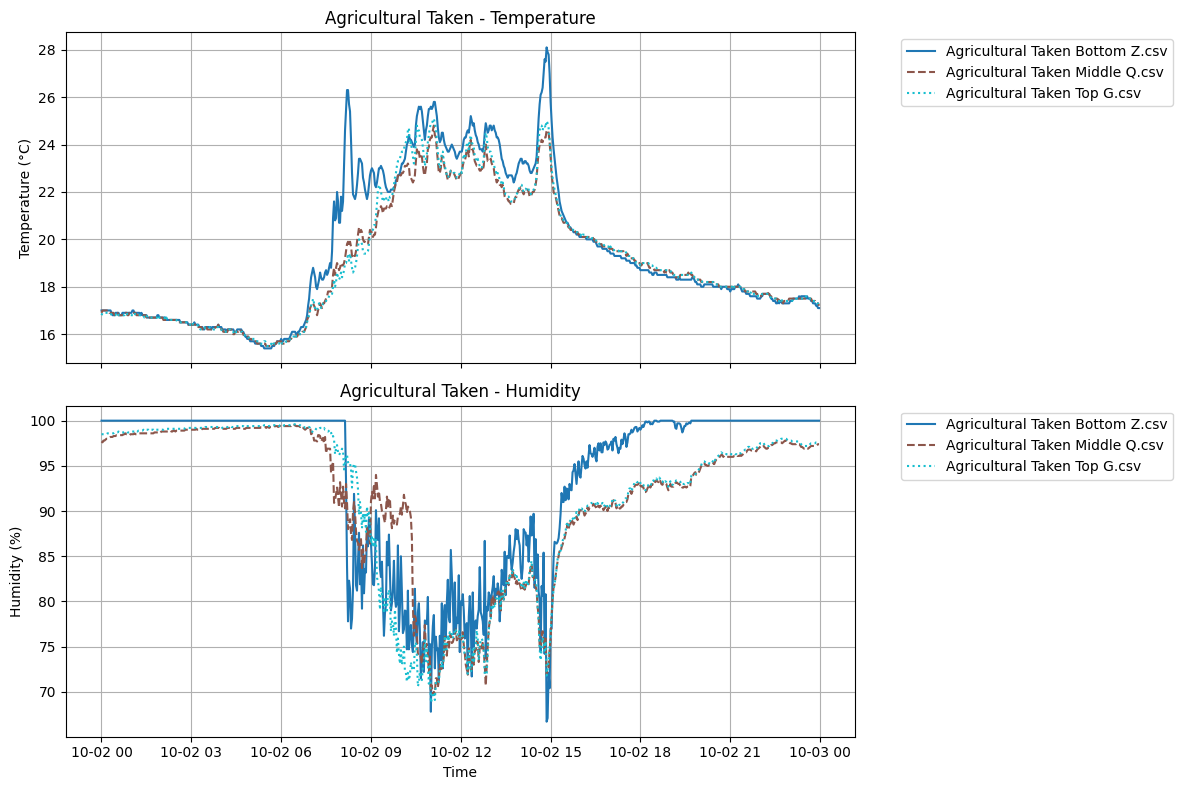

C:\Users\laank\AppData\Local\Temp\ipykernel_13352\3900997156.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(files))  # colorblind-friendly


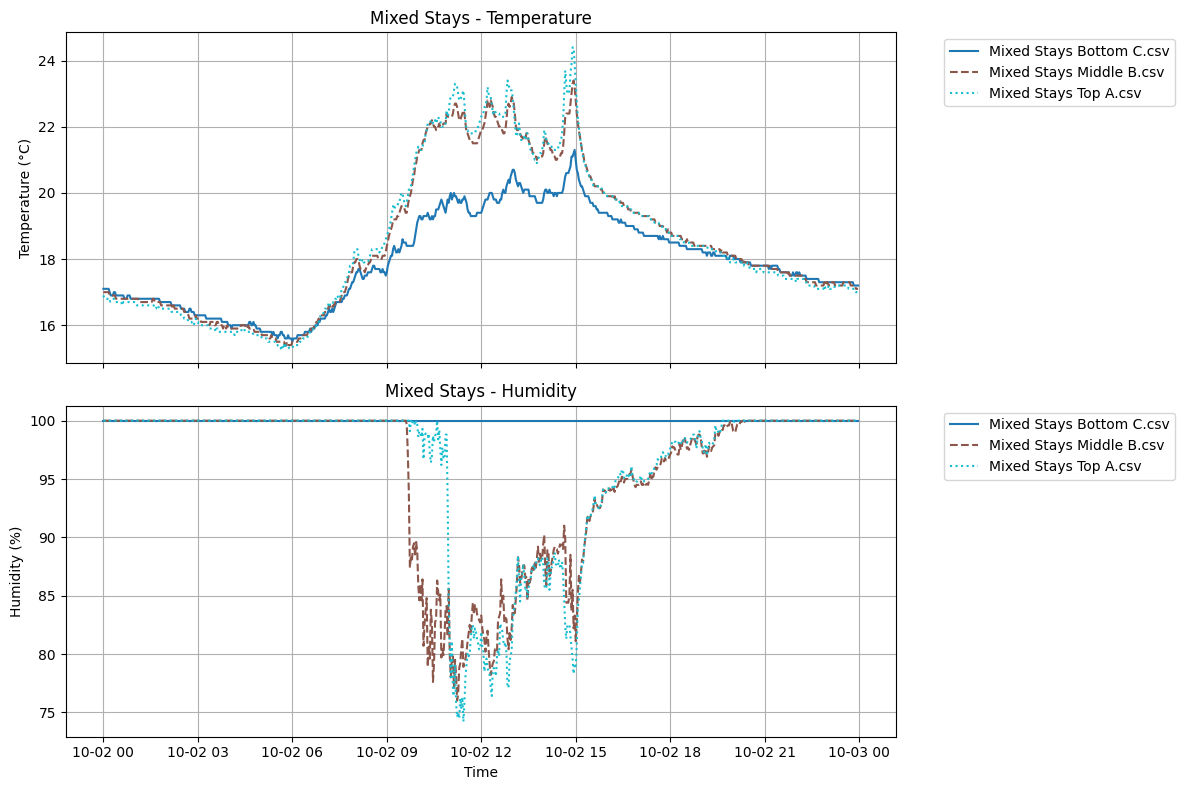

C:\Users\laank\AppData\Local\Temp\ipykernel_13352\3900997156.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(files))  # colorblind-friendly


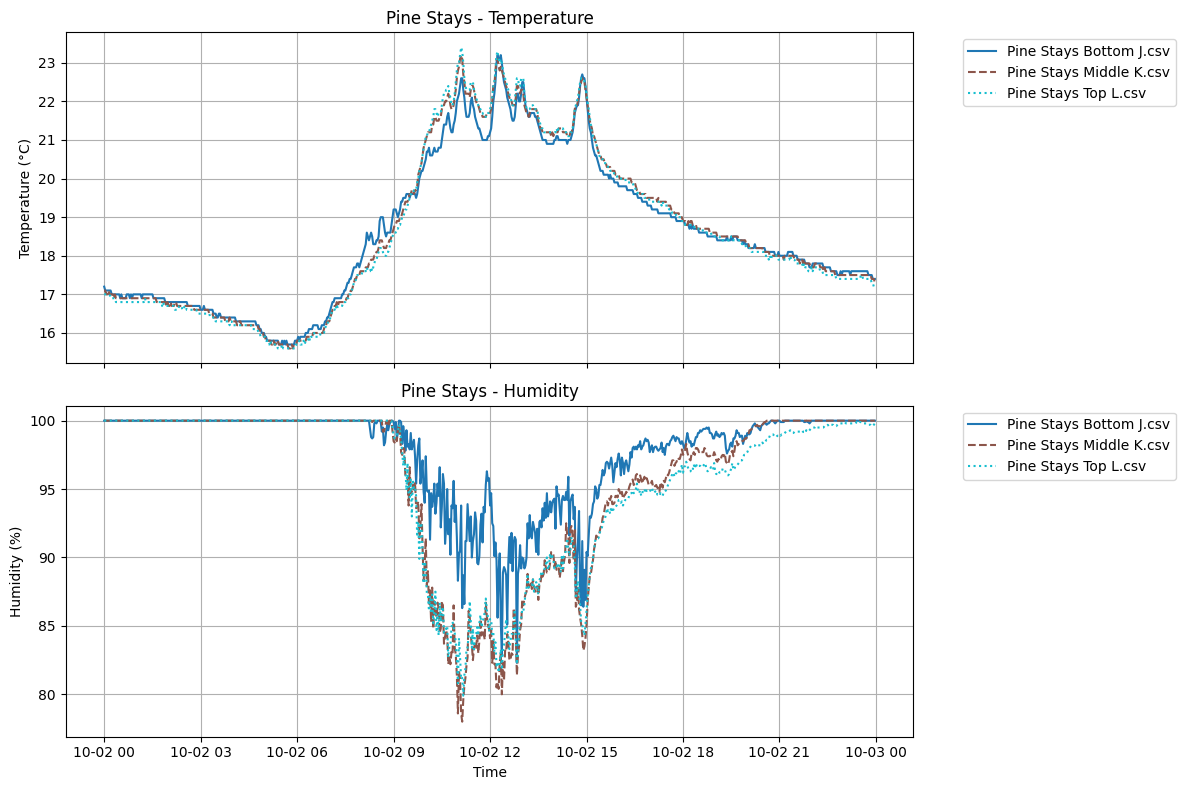

C:\Users\laank\AppData\Local\Temp\ipykernel_13352\3900997156.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10", len(files))  # colorblind-friendly


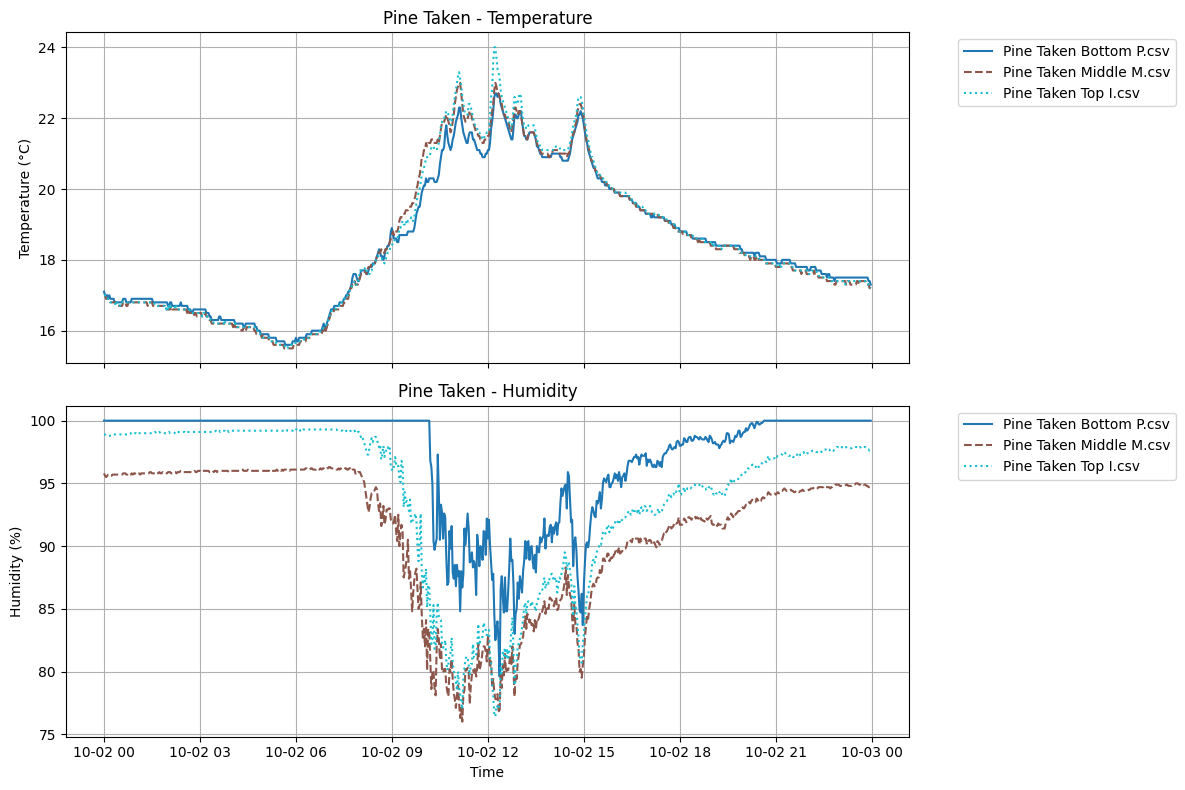

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# --- Group your files ---
groups = {
    "Agricultural Stays": [
        "Agricultural Stays Bottom noname.csv",
        "Agricultural Stays Middle H.csv",
        "Agricultural Stays Top O.csv"
    ],
    "Agricultural Taken": [
        "Agricultural Taken Bottom Z.csv",
        "Agricultural Taken Middle Q.csv",
        "Agricultural Taken Top G.csv"
    ],
    "Mixed Stays": [
        "Mixed Stays Bottom C.csv",
        "Mixed Stays Middle B.csv",
        "Mixed Stays Top A.csv"
    ],
    "Pine Stays": [
        "Pine Stays Bottom J.csv",
        "Pine Stays Middle K.csv",
        "Pine Stays Top L.csv"
    ],
    "Pine Taken": [
        "Pine Taken Bottom P.csv",
        "Pine Taken Middle M.csv",
        "Pine Taken Top I.csv"
    ]
}


start_date = pd.to_datetime("2025-10-02" + " 00:00:00")
end_date   = pd.to_datetime("2025-10-02" + " 23:59:59")

# Define a list of linestyles to cycle through
linestyles = ["-", "--", ":"]

# --- Loop through groups ---
for group_name, files in groups.items():
    colors = cm.get_cmap("tab10", len(files))  # colorblind-friendly

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    for i, name in enumerate(files):
        df = pd.read_csv(
            name,
            sep=",",
            decimal=".",
            usecols=[0, 1, 2, 3, 4],
            header=None,
            names=["ID", "Date", "Time", "Temp", "Humidity"]
        )

        df["Datetime"] = pd.to_datetime(
            df["Date"].astype(str) + " " + df["Time"].astype(str),
            errors="coerce"
        )

        df = df[(df["Datetime"] >= start_date) & (df["Datetime"] <= end_date)]

        # Pick linestyle based on index (wraps around if more than 3)
        linestyle = linestyles[i % len(linestyles)]

        # Plot temperature
        axes[0].plot(df["Datetime"], df["Temp"],
                     label=name,
                     color=colors(i),
                     linestyle=linestyle)

        # Plot humidity
        axes[1].plot(df["Datetime"], df["Humidity"],
                     label=name,
                     color=colors(i),
                     linestyle=linestyle)

    # Labels and titles
    axes[0].set_title(f"{group_name} - Temperature")
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].grid()
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    axes[1].set_title(f"{group_name} - Humidity")
    axes[1].set_ylabel("Humidity (%)")
    axes[1].set_xlabel("Time")
    axes[1].grid()
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()


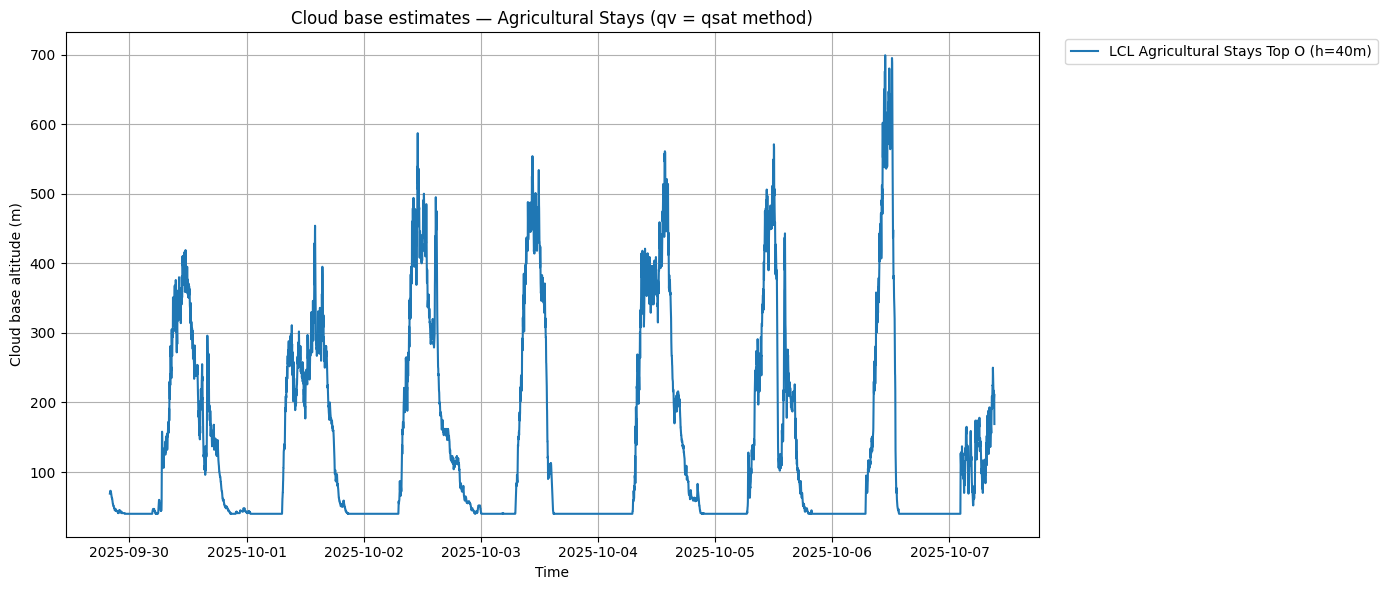

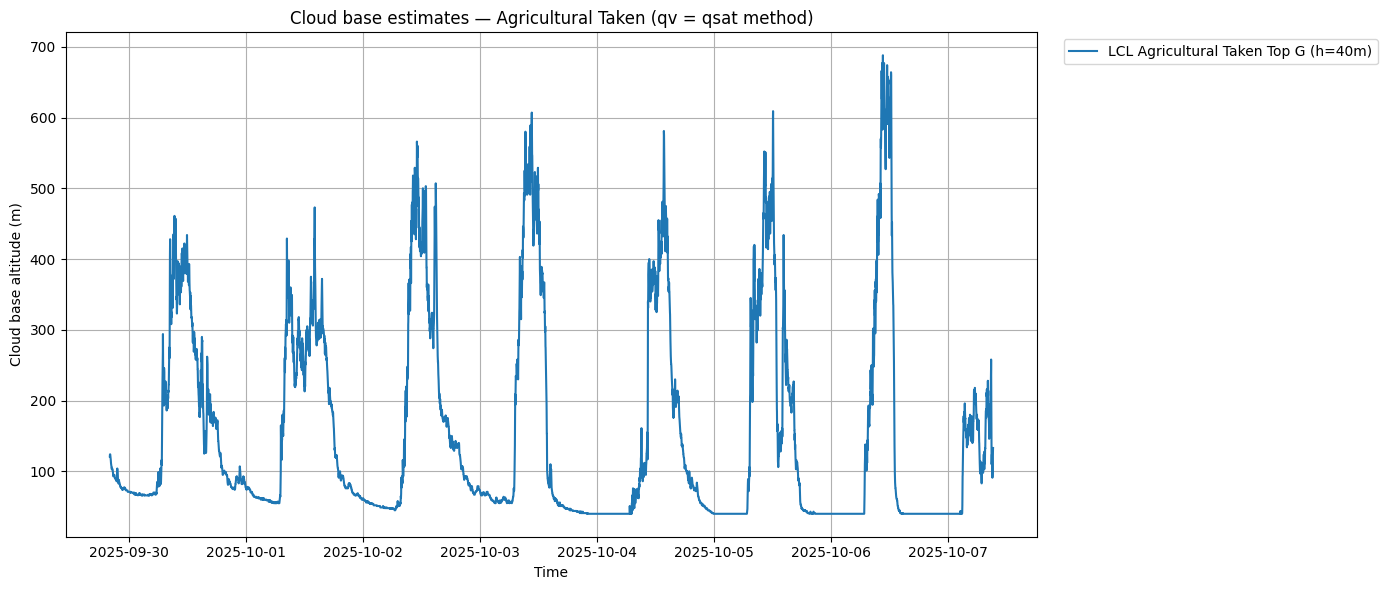

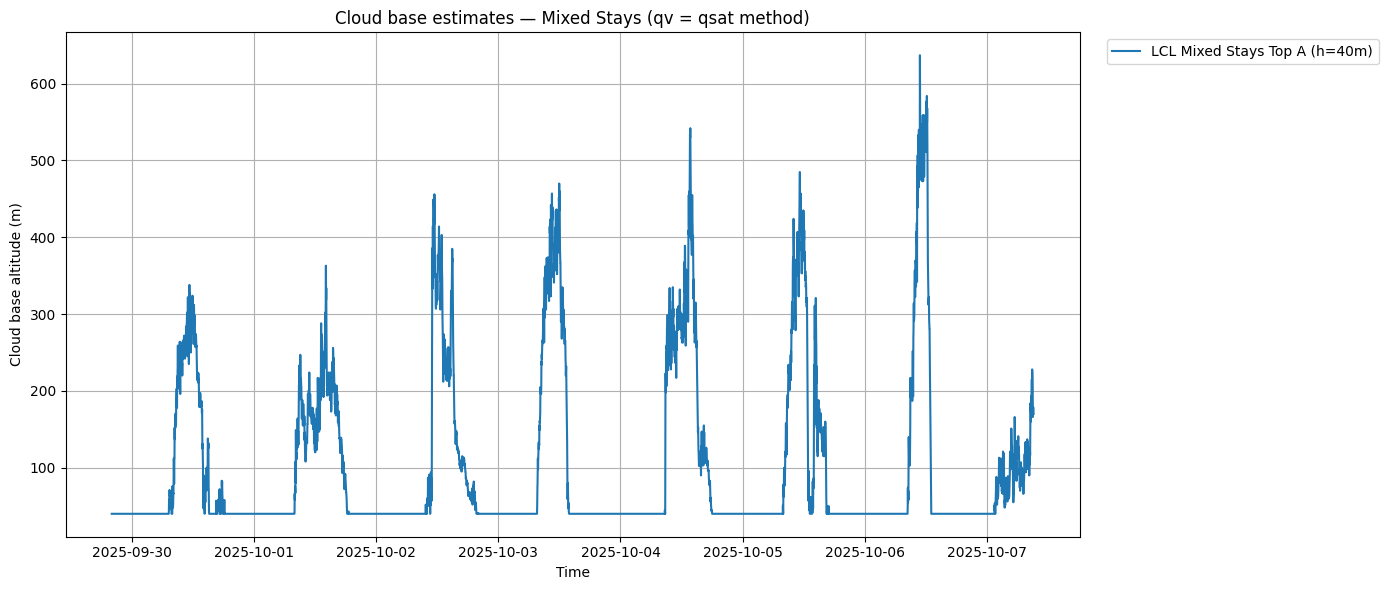

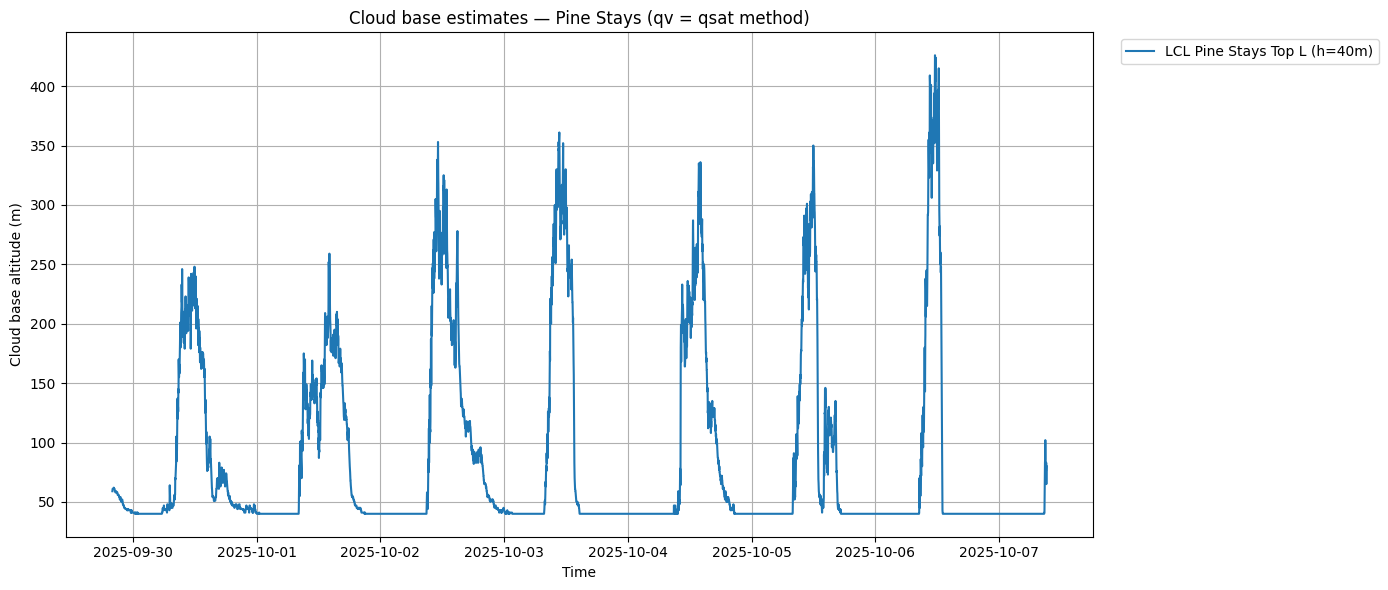

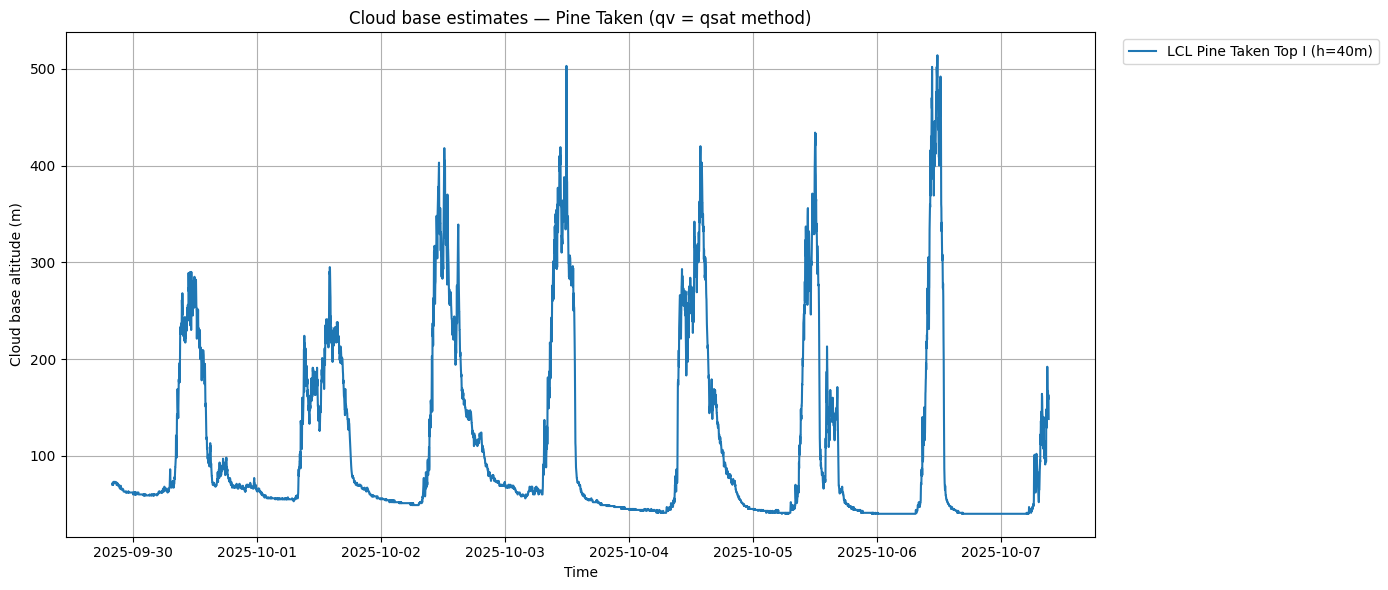

Summary (median altitudes):

Agricultural Stays:
  LCL Agricultural Stays Top O.csv : 47.0 m

Agricultural Taken:
  LCL Agricultural Taken Top G.csv : 77.0 m

Mixed Stays:
  LCL Mixed Stays Top A.csv : 40.0 m

Pine Stays:
  LCL Pine Stays Top L.csv : 40.0 m

Pine Taken:
  LCL Pine Taken Top I.csv : 63.0 m


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- define groups --- #
groups = {
    "Agricultural Stays": [
        # "Agricultural Stays Bottom noname.csv",
        # "Agricultural Stays Middle H.csv",
        "Agricultural Stays Top O.csv"
    ],
    "Agricultural Taken": [
        # "Agricultural Taken Bottom Z.csv",
        # "Agricultural Taken Middle Q.csv",
        "Agricultural Taken Top G.csv"
    ],
    "Mixed Stays": [
        # "Mixed Stays Bottom C.csv",
        # "Mixed Stays Middle B.csv",
        "Mixed Stays Top A.csv"
    ],
    "Pine Stays": [
        # "Pine Stays Bottom J.csv",
        # "Pine Stays Middle K.csv",
        "Pine Stays Top L.csv"
    ],
    "Pine Taken": [
        # "Pine Taken Bottom P.csv",
        # "Pine Taken Middle M.csv",
        "Pine Taken Top I.csv"
    ]
}

# --- assign heights --- #
heights = {}
for group, files in groups.items():
    for f in files:
        if "Bottom" in f:
            heights[f] = 0
        elif "Middle" in f:
            heights[f] = 20
        elif "Top" in f:
            heights[f] = 40
        else:
            heights[f] = 0

# --- constants --- #
Rd = 287.05
Rv = 461.5
g  = 9.81
dtdz = -9.8/1000
p_surface = 85000  # Pa

# --- helper functions --- #
def esat(Tk):
    return 610.78 * np.exp(17.2694 * (Tk - 273.16) / (Tk - 35.86))

def qsat(Tk, p):
    e = esat(Tk)
    return Rd * e / (Rv * (p - e) + Rd * e)

def lcl_from_qv(T0, RH0, p0=p_surface, zmax=4000, dz=1):
    T0k = T0 + 273.15
    e0 = (RH0/100.0) * esat(T0k)
    w = (0.622 * e0) / (p0 - e0)
    qv = w / (1 + w)

    z = np.arange(0, zmax+dz, dz)
    T_profile = T0k + dtdz * z
    a = 1 + (dtdz * z) / T0k
    b = -g / (Rd * dtdz)
    p_profile = p0 * a**-b
    qsat_profile = qsat(T_profile, p_profile)

    diff = np.abs(qsat_profile - qv)
    iz = np.argmin(diff)
    return z[iz]

# --- load all files --- #
dfs = {}
for group, files in groups.items():
    for fname in files:
        df = pd.read_csv(
            fname, sep=",", decimal=".", header=None,
            usecols=[0,1,2,3,4], names=["ID","Date","Time","Temp","Humidity"]
        )
        df["Datetime"] = pd.to_datetime(df["Date"].astype(str)+" "+df["Time"].astype(str), errors="coerce")
        df = df.dropna(subset=["Datetime"]).set_index("Datetime")[["Temp","Humidity"]]
        df = df[(df["Temp"].between(-40,60)) & (df["Humidity"].between(0,100))]
        dfs[fname] = df

# --- common time index --- #
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
common_index = pd.date_range(start, end, freq="1min")

for fname, df in dfs.items():
    df = df.reindex(df.index.union(common_index)).sort_index()
    df = df.interpolate(method="time").reindex(common_index)
    dfs[fname] = df

# --- compute LCL --- #
results = {}
for fname, df in dfs.items():
    T, RH = df["Temp"].values, df["Humidity"].values
    LCL_list = [lcl_from_qv(t, rh, p_surface) for t, rh in zip(T, RH)]
    LCL_arr = np.array(LCL_list)
    CloudBase_alt_m = heights[fname] + LCL_arr
    out = pd.DataFrame({
        "Temp": T, "RH": RH,
        "LCL_m": LCL_arr,
        "CloudBase_alt_m": CloudBase_alt_m
    }, index=common_index)
    results[fname] = out

# --- plotting per group --- #
for group, files in groups.items():
    plt.figure(figsize=(14,6))
    files_sorted = sorted(files, key=lambda f: heights[f])
    for f in files_sorted:
        plt.plot(results[f].index, results[f]["CloudBase_alt_m"],
            label=f"LCL {f.replace('.csv','')} (h={heights[f]}m)")
    plt.ylabel("Cloud base altitude (m)")
    plt.xlabel("Time")
    plt.title(f"Cloud base estimates — {group} (qv = qsat method)")
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# --- summary --- #
print("Summary (median altitudes):")
for group, files in groups.items():
    print(f"\n{group}:")
    for f in files:
        print(f"  LCL {f} : {np.nanmedian(results[f]['CloudBase_alt_m']):.1f} m")


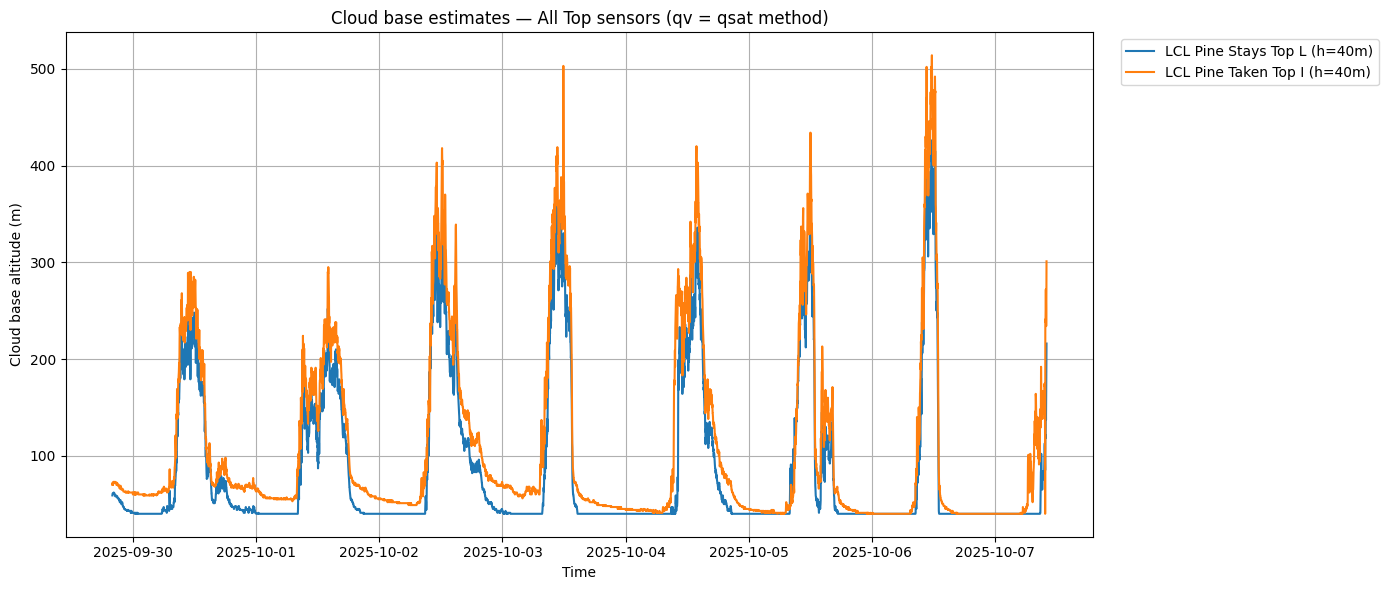

Summary (median altitudes):
  LCL Pine Stays Top L.csv : 40.0 m
  LCL Pine Taken Top I.csv : 63.0 m


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- define only Top sensors --- #
groups = {
    "All Tops": [
        # "Agricultural Stays Top O.csv",
        # "Agricultural Taken Top G.csv",
        # "Mixed Stays Top A.csv",
        "Pine Stays Top L.csv",
        "Pine Taken Top I.csv"
    ]
}

# --- assign heights --- #
heights = {f: 40 for f in groups["All Tops"]}  # all tops = 40 m (adjust if needed)

# --- datetime range (edit these!) --- #
start_date = pd.to_datetime("2025-10-02 00:00:00")
end_date   = pd.to_datetime("2025-10-02 23:59:59")

# --- constants --- #
Rd = 287.05
Rv = 461.5
g  = 9.81
dtdz = -9.8/1000
p_surface = 85000  # Pa

# --- helper functions --- #
def esat(Tk):
    return 610.78 * np.exp(17.2694 * (Tk - 273.16) / (Tk - 35.86))

def qsat(Tk, p):
    e = esat(Tk)
    return Rd * e / (Rv * (p - e) + Rd * e)

def lcl_from_qv(T0, RH0, p0=p_surface, zmax=4000, dz=1):
    T0k = T0 + 273.15
    e0 = (RH0/100.0) * esat(T0k)
    w = (0.622 * e0) / (p0 - e0)
    qv = w / (1 + w)

    z = np.arange(0, zmax+dz, dz)
    T_profile = T0k + dtdz * z
    a = 1 + (dtdz * z) / T0k
    b = -g / (Rd * dtdz)
    p_profile = p0 * a**-b
    qsat_profile = qsat(T_profile, p_profile)

    diff = np.abs(qsat_profile - qv)
    iz = np.argmin(diff)
    return z[iz]

# --- load all files --- #
dfs = {}
for fname in groups["All Tops"]:
    df = pd.read_csv(
        fname, sep=",", decimal=".", header=None,
        usecols=[0,1,2,3,4], names=["ID","Date","Time","Temp","Humidity"]
    )
    df["Datetime"] = pd.to_datetime(df["Date"].astype(str)+" "+df["Time"].astype(str), errors="coerce")
    df = df.dropna(subset=["Datetime"]).set_index("Datetime")[["Temp","Humidity"]]
    df = df[(df["Temp"].between(-40,60)) & (df["Humidity"].between(0,100))]
    # apply date range filter
    # df = df[(df.index >= start_date) & (df.index <= end_date)]
    dfs[fname] = df

# --- common time index --- #
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
common_index = pd.date_range(start, end, freq="1min")

for fname, df in dfs.items():
    df = df.reindex(df.index.union(common_index)).sort_index()
    df = df.interpolate(method="time").reindex(common_index)
    dfs[fname] = df

# --- compute LCL --- #
results = {}
for fname, df in dfs.items():
    T, RH = df["Temp"].values, df["Humidity"].values
    LCL_list = [lcl_from_qv(t, rh, p_surface) for t, rh in zip(T, RH)]
    LCL_arr = np.array(LCL_list)
    CloudBase_alt_m = heights[fname] + LCL_arr
    out = pd.DataFrame({
        "Temp": T, "RH": RH,
        "LCL_m": LCL_arr,
        "CloudBase_alt_m": CloudBase_alt_m
    }, index=common_index)
    results[fname] = out

# --- plotting (only Tops) --- #
plt.figure(figsize=(14,6))
for f in groups["All Tops"]:
    plt.plot(results[f].index, results[f]["CloudBase_alt_m"],
             label=f"LCL {f.replace('.csv','')} (h={heights[f]}m)")
plt.ylabel("Cloud base altitude (m)")
plt.xlabel("Time")
plt.title("Cloud base estimates — All Top sensors (qv = qsat method)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- summary --- #
print("Summary (median altitudes):")
for f in groups["All Tops"]:
    print(f"  LCL {f} : {np.nanmedian(results[f]['CloudBase_alt_m']):.1f} m") #median is niet logisch hier


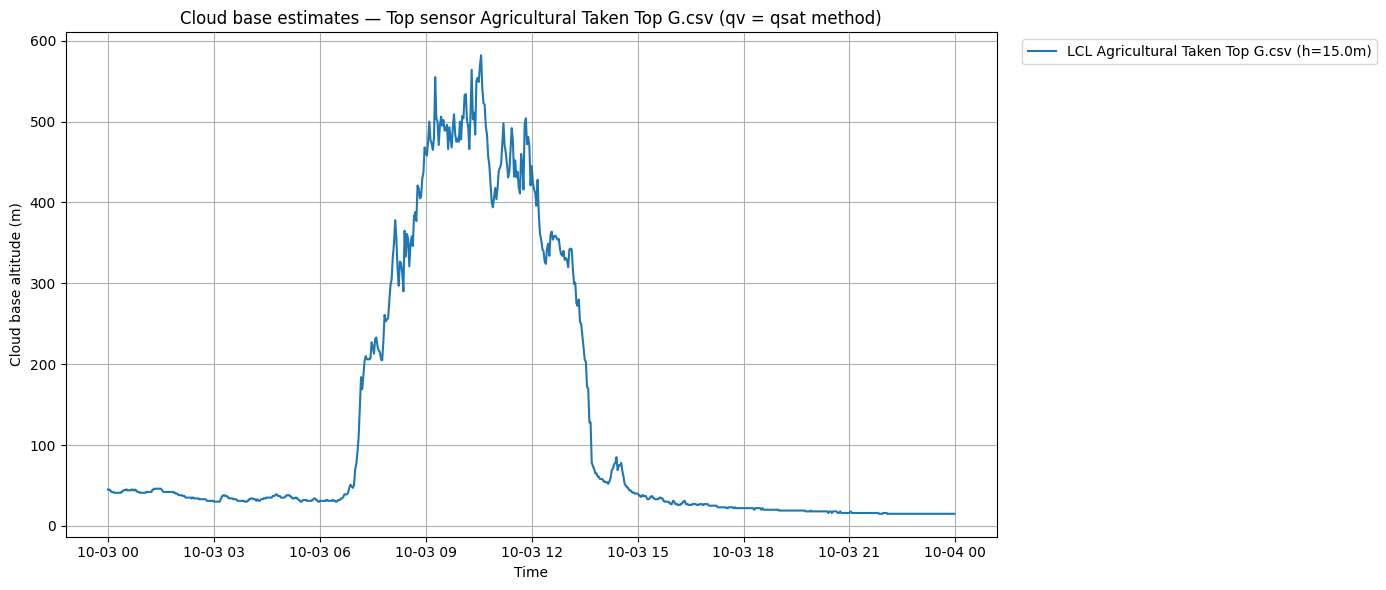

Summary (median altitudes):
  LCL Agricultural Taken Top G.csv : 35.0 m


In [13]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# --- files and heights (only Top sensors) ---
csv_files = [
    # "Agricultural Stays Top O.csv",
    "Agricultural Taken Top G.csv",
    # "Mixed Stays Top A.csv",
    # "Mixed Stays Middle B.csv",
    # "Pine Stays Top L.csv",
    # "Pine Taken Top I.csv"
]
heights = {f: 15.0 for f in csv_files}  # all tops = 40 m (adjust if needed)

# --- datetime range (edit as needed) ---
start_date = pd.to_datetime("2025-10-03 00:00:00")
end_date   = pd.to_datetime("2025-10-03 23:59:59")
freq = "1min"  # resample frequency

# --- constants ---
Rd = 287.05   # dry air gas constant (J/kg/K) --> source
Rv = 461.5    # water vapor gas constant (J/kg/K) --> deRoode
g  = 9.81     # m/s2
dtdz = -9.8/1000  # dry adiabatic lapse rate (K/m)
p_surface = 85000  # Pa (approx Sierra Yalijux, ~850 hPa)

# --- helper functions ---
def esat(Tk):
    """Saturation vapor pressure (Pa), T in K"""
    return 611.3 * np.exp(17.2694 * (Tk - 273.15) / (Tk - 35.86))

def qsat(Tk, p):
    """Saturation specific humidity"""
    e = esat(Tk)
    return Rd * e / (Rv * (p - e) + Rd * e)

def lcl_from_qv(T0, RH0, p0=p_surface, zmax=4000, dz=1):
    """
    Find LCL height by intersecting constant qv with qsat(z).
    T0 in °C, RH0 in %, p0 in Pa
    """
    T0k = T0 + 273.15  # temp at surface in K
    e0 = (RH0/100.0) * esat(T0k)
    r = (0.622 * e0) / (p0 - e0) # --> from ideal gas law for moist air stull2017
    qv = r / (1 + r)  # --> specific humidity

    z = np.arange(0, zmax+dz, dz)
    T_profile = T0k + dtdz * z
    a = 1 + (dtdz * z) / T0k
    b = -g / (Rd * dtdz)
    p_profile = p0 * a**-b

    qsat_profile = qsat(T_profile, p_profile)

    # Find where qv crosses qsat
    diff = np.abs(qsat_profile - qv)
    iz = np.argmin(diff)
    return z[iz]  # meters above sensor

# --- load and preprocess ---
dfs = {}
for fname in csv_files:
    df = pd.read_csv(
        fname, sep=",", decimal=".", header=None,
        usecols=[0,1,2,3,4], names=["ID","Date","Time","Temp","Humidity"]
    )
    df["Datetime"] = pd.to_datetime(
        df["Date"].astype(str)+" "+df["Time"].astype(str), errors="coerce"
    )
    df = df.dropna(subset=["Datetime"]).set_index("Datetime")[["Temp","Humidity"]]
    df = df[(df["Temp"].between(-40,60)) & (df["Humidity"].between(0,100))]
    df = df[(df.index >= start_date) & (df.index <= end_date)]
    dfs[fname] = df

# --- common time index ---
start = max(df.index.min() for df in dfs.values())
end   = min(df.index.max() for df in dfs.values())
if start >= end:
    start = min(df.index.min() for df in dfs.values())
    end   = max(df.index.max() for df in dfs.values())
common_index = pd.date_range(start, end, freq=freq)

for fname, df in dfs.items():
    df = df.reindex(df.index.union(common_index)).sort_index()
    df = df.interpolate(method="time").reindex(common_index)
    dfs[fname] = df

# --- compute LCL via qv = qsat method ---
results = {}
for fname, df in dfs.items():
    T, RH = df["Temp"].values, df["Humidity"].values
    LCL_list = [lcl_from_qv(t, rh, p_surface) for t, rh in zip(T, RH)]
    LCL_arr = np.array(LCL_list)  # --> gets CBH from sensor
    CloudBase = heights[fname] + LCL_arr  # --> adds sensor's tree height, gets CBH from ground
    out = pd.DataFrame({
        "Temp": T, "RH": RH,
        "LCL_m": LCL_arr,
        "CloudBase_alt_m": CloudBase
    }, index=common_index)
    results[fname] = out

# --- plotting ---
plt.figure(figsize=(14,6))
for f in csv_files:
    plt.plot(results[f].index, results[f]["CloudBase_alt_m"],
             label=f"LCL {f} (h={heights[f]}m)")
plt.ylabel("Cloud base altitude (m)")
plt.xlabel("Time")
plt.title(f"Cloud base estimates — Top sensor {f} (qv = qsat method)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- summary ---
print("Summary (median altitudes):")
for f in csv_files:
    print(f"  LCL {f} : {np.nanmedian(results[f]['CloudBase_alt_m']):.1f} m")
